<a href="https://www.kaggle.com/code/aamir28/classifying-date-fruit-varieties?scriptVersionId=345947487" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 40%, #c9822f 72%, #e8b84b 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">898 Date Fruit Images &middot; 7 Varieties &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 36px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Classifying Date Fruit Varieties from Image Features</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at 34 morphological, shape, and color features extracted from date fruit images &mdash; walking from raw data through class balance, distributions, correlations, and a small multi-class classification model.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">898</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Images</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">34</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Features</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">7</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Varieties</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the dataset. This one ships as an .xlsx rather than a .csv, so we read it with pandas' Excel engine.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (date-skin maroon -> honey gold)
MAROON, UMBER, AMBER, HONEY, TEAL = '#3a1410', '#7a3b1e', '#c9822f', '#e8b84b', '#2f8f80'

df = pd.read_excel('/kaggle/input/datasets/muratkokludataset/date-fruit-datasets/Date_Fruit_Datasets/Date_Fruit_Datasets.xlsx')
df.shape

(898, 35)

<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and missingness before doing anything else.</p>
</div>


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           898 non-null    int64  
 1   PERIMETER      898 non-null    float64
 2   MAJOR_AXIS     898 non-null    float64
 3   MINOR_AXIS     898 non-null    float64
 4   ECCENTRICITY   898 non-null    float64
 5   EQDIASQ        898 non-null    float64
 6   SOLIDITY       898 non-null    float64
 7   CONVEX_AREA    898 non-null    int64  
 8   EXTENT         898 non-null    float64
 9   ASPECT_RATIO   898 non-null    float64
 10  ROUNDNESS      898 non-null    float64
 11  COMPACTNESS    898 non-null    float64
 12  SHAPEFACTOR_1  898 non-null    float64
 13  SHAPEFACTOR_2  898 non-null    float64
 14  SHAPEFACTOR_3  898 non-null    float64
 15  SHAPEFACTOR_4  898 non-null    float64
 16  MeanRR         898 non-null    float64
 17  MeanRG         898 non-null    float64
 18  MeanRB    

<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The dataset loads as a single flat table: <b>898 rows &times; 35 columns</b>. Each row is one date fruit image, with 34 numeric features covering morphology (area, perimeter, axis lengths), shape factors, and RGB color-channel statistics (means, standard deviations, skewness, kurtosis, entropy, and wavelet-transform coefficients), plus the <code>Class</code> label naming one of 7 genetic varieties.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness &amp; Duplicates</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check for gaps and exact duplicate rows.</p>
</div>


In [3]:
print(f"Total missing values: {df.isna().sum().sum()}")
print(f"Exact duplicate rows: {df.duplicated().sum()}")

Total missing values: 0
Exact duplicate rows: 0


<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>Zero</b> missing values and <b>zero</b> duplicate rows &mdash; genuinely clean, in contrast to some of the messier real-world datasets in this series. That's consistent with this being a curated academic dataset behind a published paper (Koklu et al., 2021) rather than a raw scrape: every feature here was computed once, deterministically, from a processed image, so there's no self-reporting or manual entry to introduce gaps.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Class Balance</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check how evenly the 7 varieties are represented — this matters for how we should read any accuracy number later.</p>
</div>


In [4]:
class_counts = df['Class'].value_counts()
class_counts

Class
DOKOL     204
SAFAVI    199
ROTANA    166
DEGLET     98
SOGAY      94
IRAQI      72
BERHI      65
Name: count, dtype: int64

<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The 7 varieties are not evenly represented: <b>DOKOL</b> has <b>204</b> images while <b>BERHI</b> has only <b>65</b> &mdash; a <b>3.14&times;</b> imbalance ratio between the largest and smallest class. This is worth keeping in mind for the rest of the notebook: a classifier could reach reasonable-looking overall accuracy just by favoring the larger classes, which is why we report a macro-averaged metric alongside plain accuracy in the model section below.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Univariate Distributions</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Look at the shape of the two strongest class-separating features, identified by an ANOVA F-test below.</p>
</div>


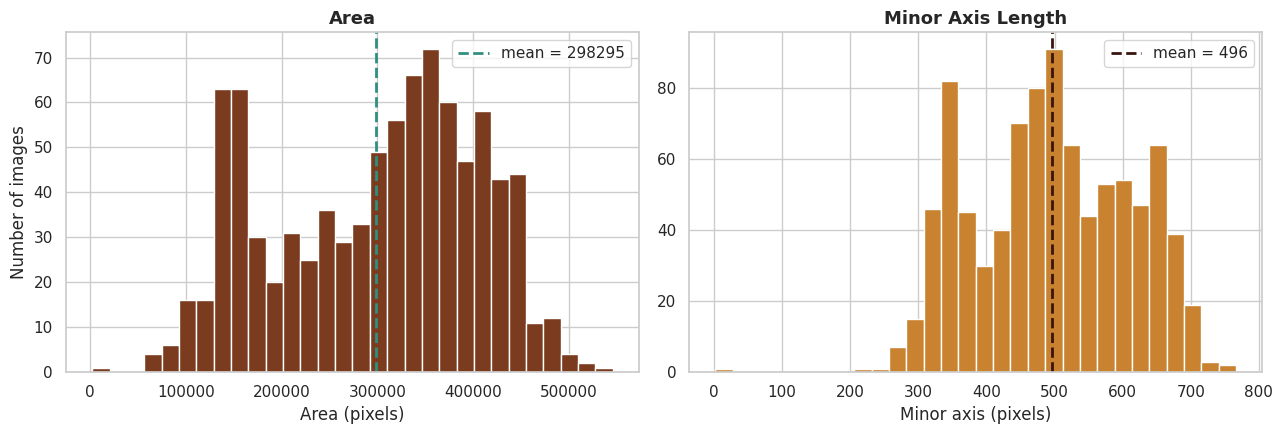

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['AREA'], bins=30, color=UMBER, edgecolor='white')
axes[0].axvline(df['AREA'].mean(), color=TEAL, linestyle='--', linewidth=2,
                 label=f"mean = {df['AREA'].mean():.0f}")
axes[0].set_title('Area', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Area (pixels)')
axes[0].set_ylabel('Number of images')
axes[0].legend()

axes[1].hist(df['MINOR_AXIS'], bins=30, color=AMBER, edgecolor='white')
axes[1].axvline(df['MINOR_AXIS'].mean(), color=MAROON, linestyle='--', linewidth=2,
                 label=f"mean = {df['MINOR_AXIS'].mean():.0f}")
axes[1].set_title('Minor Axis Length', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Minor axis (pixels)')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Both distributions are broad and multi-modal rather than a single clean bell curve &mdash; a visible sign that we're looking at a mixture of 7 differently-sized varieties layered on top of each other. Neither variable looks badly skewed by extreme outliers the way GitHub stars or income data typically are; this is measured, calibrated image data, not self-reported or naturally power-law-shaped.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">The Size Gradient Across Varieties</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Break AREA down by class to see how much of the spread above is really just variety-to-variety size difference.</p>
</div>


In [6]:
area_by_class = df.groupby('Class')['AREA'].agg(['mean', 'median', 'std']).round(0).sort_values('mean')
area_by_class

,mean,median,std
Class,,,
DOKOL,145147.0,146460.0,29188.0
DEGLET,233743.0,228354.0,41394.0
SOGAY,286873.0,284757.0,47199.0
SAFAVI,334368.0,335351.0,43841.0
ROTANA,387116.0,387775.0,42126.0
BERHI,405213.0,409032.0,50350.0
IRAQI,433984.0,439848.0,36083.0


<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A clean, nearly 3&times; range: mean area climbs from <b>145,147</b> (DOKOL, the smallest variety) to <b>433,984</b> (IRAQI, the largest). Size alone does substantial work separating these varieties, which lines up with what the F-statistic ranking below confirms directly &mdash; and matches simple intuition, since date varieties really do differ noticeably in fruit size.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Visualizing the Size Gradient</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The same comparison as a boxplot, ordered by median size.</p>
</div>


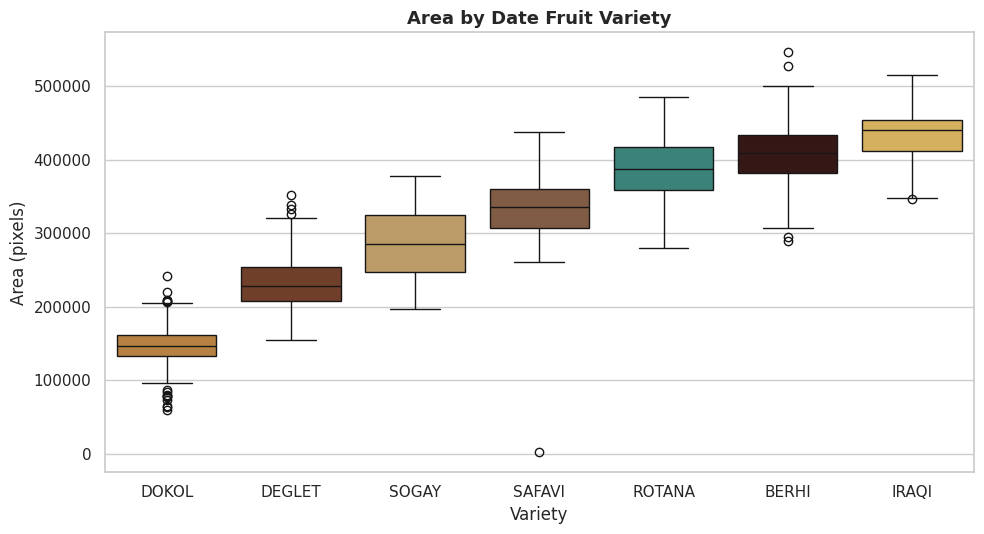

In [7]:
class_order = df.groupby('Class')['AREA'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=df, x='Class', y='AREA', order=class_order, hue='Class',
            palette=sns.color_palette([MAROON, UMBER, AMBER, HONEY, TEAL, '#8a5a3a', '#c9a05a']),
            legend=False, ax=ax)
ax.set_title('Area by Date Fruit Variety', fontsize=13, fontweight='bold')
ax.set_xlabel('Variety')
ax.set_ylabel('Area (pixels)')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The boxplot shows real separation between neighboring varieties but also real overlap &mdash; SAFAVI, ROTANA, and BERHI in particular sit close enough together that area alone wouldn't cleanly tell them apart. Size is a strong signal here, not a perfect one, which is exactly the kind of nuance a single summary statistic like the F-test score can hide.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Precise Redundancy Check</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">With 34 features, some are bound to be closely related. Check the most extreme cases precisely rather than assuming from the correlation value alone.</p>
</div>


In [8]:
numeric_cols = df.columns.drop('Class')
corr = df[numeric_cols].corr()

c = corr.to_numpy().copy()
np.fill_diagonal(c, 0)
c = pd.DataFrame(c, index=corr.index, columns=corr.columns)
top_pair = c.abs().unstack().sort_values(ascending=False)

# check the single strongest pair precisely: is it identical, or just perfectly linear?
a, b = 'MeanRG', 'ALLdaub4RG'
exact_equal = (df[a] == df[b]).all()
ratio_std = (df[a] / df[b]).std()
print(f"Correlation({a}, {b}) = {df[a].corr(df[b]):.4f}")
print(f"Exactly equal in every row? {exact_equal}")
print(f"Std of the ratio {a}/{b}: {ratio_std:.6f}  (near-zero means a near-constant scale factor)")
print(f"Mean ratio: {(df[a] / df[b]).mean():.4f}")

Correlation(MeanRG, ALLdaub4RG) = 1.0000
Exactly equal in every row? False
Std of the ratio MeanRG/ALLdaub4RG: 0.000100  (near-zero means a near-constant scale factor)
Mean ratio: 2.0000


<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<code>MeanRG</code> and <code>ALLdaub4RG</code> correlate at a perfect <b>1.000</b> &mdash; but they are <b>not identical values</b>. The ratio between them is essentially constant at <b>2.00</b> across every row, meaning <code>MeanRG</code> is a simple linear rescaling of the wavelet-transform feature, not a copy of it. This is a more precise (and more interesting) finding than "these two columns are duplicates" &mdash; it reflects how the daub4 wavelet coefficients were engineered directly from the raw channel statistics in the original feature-extraction pipeline, rather than a data error.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Correlation Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">With 34 features, a full heatmap would be unreadable — scan a representative subset covering morphology, shape, and color instead.</p>
</div>


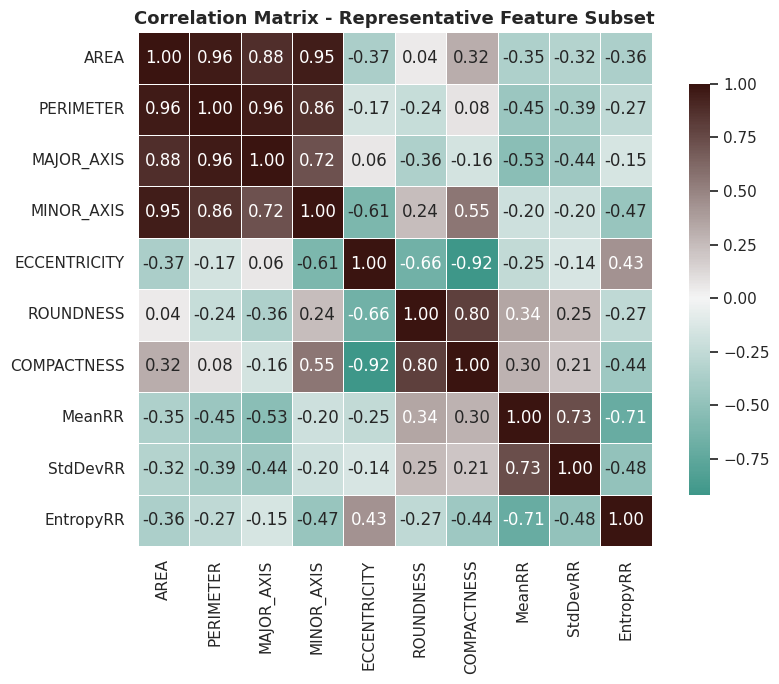

In [9]:
subset_cols = ['AREA', 'PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'ECCENTRICITY',
               'ROUNDNESS', 'COMPACTNESS', 'MeanRR', 'StdDevRR', 'EntropyRR']

corr_subset = df[subset_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap=sns.blend_palette([TEAL, '#f4f4f4', MAROON], as_cmap=True),
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Representative Feature Subset', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Even in this trimmed 10-feature subset, the morphology block (AREA, PERIMETER, MAJOR_AXIS, MINOR_AXIS) is tightly inter-correlated (mostly above 0.85), as expected since they're all describing the same physical outline. <b>ECCENTRICITY</b> and <b>ROUNDNESS</b> move strongly opposite each other (a rounder shape is by definition less eccentric), while the color-channel statistics (<b>MeanRR</b>, <b>StdDevRR</b>, <b>EntropyRR</b>) are comparatively independent of the shape block &mdash; a useful sign that shape and color are capturing genuinely different information rather than redundant versions of the same signal.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Which Features Separate Classes Best</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Rank all 34 features by how strongly they distinguish the 7 varieties, using an ANOVA F-statistic.</p>
</div>


In [10]:
from sklearn.feature_selection import f_classif

X_all = df[numeric_cols].values
y_all = df['Class'].values

f_stats, p_vals = f_classif(X_all, y_all)
f_ranking = pd.Series(f_stats, index=numeric_cols).sort_values(ascending=False)
f_ranking.head(10)

MINOR_AXIS       983.658095
CONVEX_AREA      901.508223
AREA             890.615649
PERIMETER        870.474526
EQDIASQ          843.806968
MAJOR_AXIS       624.198884
ALLdaub4RR       612.918760
MeanRR           612.908703
SkewRG           533.286548
SHAPEFACTOR_2    441.883941
dtype: float64

<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Size and shape features dominate the top of the ranking: <b>MINOR_AXIS</b>, <b>CONVEX_AREA</b>, <b>AREA</b>, <b>PERIMETER</b>, and <b>EQDIASQ</b> take the top 5 spots, all substantially ahead of any pure color feature. This is a genuine, useful finding for anyone building a lighter-weight classifier on this data: a handful of basic morphological measurements carry most of the class-separating signal, and the more exotic wavelet and entropy features contribute comparatively little on their own.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Shape vs. Color, Head to Head</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Directly compare the single best shape feature against the single best color feature at telling varieties apart.</p>
</div>


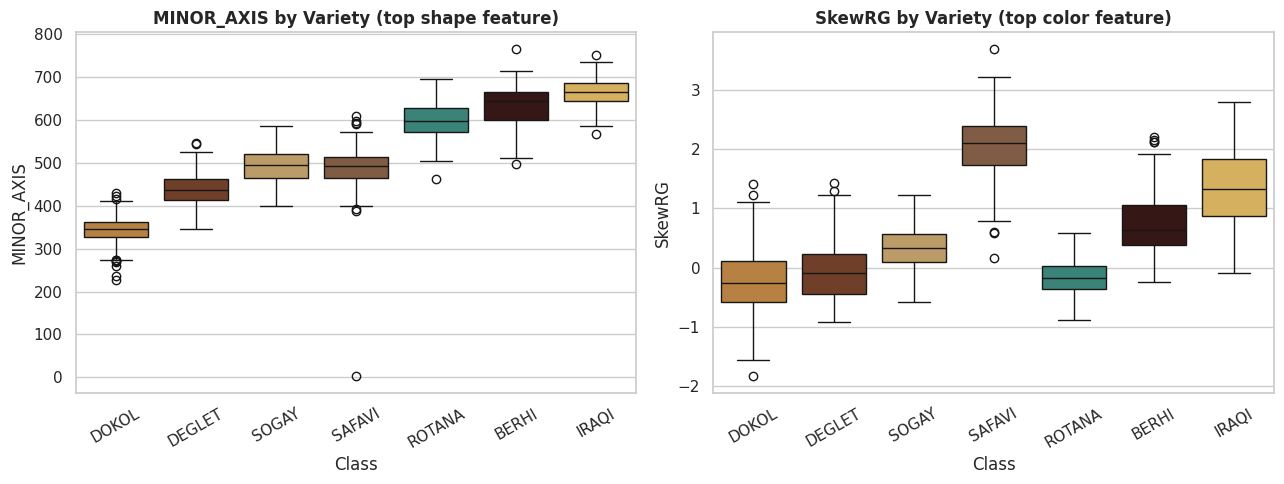

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Class', y='MINOR_AXIS', order=class_order, hue='Class',
            palette=sns.color_palette([MAROON, UMBER, AMBER, HONEY, TEAL, '#8a5a3a', '#c9a05a']),
            legend=False, ax=axes[0])
axes[0].set_title('MINOR_AXIS by Variety (top shape feature)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Class', y='SkewRG', order=class_order, hue='Class',
            palette=sns.color_palette([MAROON, UMBER, AMBER, HONEY, TEAL, '#8a5a3a', '#c9a05a']),
            legend=False, ax=axes[1])
axes[1].set_title('SkewRG by Variety (top color feature)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Side by side, the gap in usefulness is visible, not just numerical: <b>MINOR_AXIS</b> shows a clear, mostly-monotonic staircase across the ordered varieties, while <b>SkewRG</b> (the strongest color feature by F-statistic) shows real differences between some class pairs but nowhere near the same clean ordering, with much more overlapping spread. Color statistics carry real signal here &mdash; just visibly less of it than basic shape and size.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Small Multi-Class Model</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Combining all 34 features into a Random Forest classifier, checking both plain accuracy and a macro-averaged metric given the class imbalance found earlier.</p>
</div>


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

X = df[numeric_cols].values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print(f"Accuracy:        {accuracy_score(y_test, y_pred):.3f}")
print(f"Macro F1:        {f1_score(y_test, y_pred, average='macro'):.3f}")
print()
print(classification_report(y_test, y_pred))

Accuracy:        0.917
Macro F1:        0.900

              precision    recall  f1-score   support

       BERHI       0.92      0.92      0.92        13
      DEGLET       0.75      0.75      0.75        20
       DOKOL       0.95      0.95      0.95        41
       IRAQI       0.93      0.93      0.93        14
      ROTANA       1.00      0.97      0.98        33
      SAFAVI       0.97      0.95      0.96        40
       SOGAY       0.76      0.84      0.80        19

    accuracy                           0.92       180
   macro avg       0.90      0.90      0.90       180
weighted avg       0.92      0.92      0.92       180



<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A 200-tree Random Forest using all 34 features reaches <b>91.7%</b> accuracy and a <b>0.900</b> macro F1 &mdash; close to (and consistent with) the 92.2&ndash;92.8% range reported in the original paper using logistic regression, an artificial neural network, and a stacked combination of the two. The per-class report holds a genuine surprise: <b>BERHI</b>, the smallest class by far (only 65 images total), actually scores a strong <b>0.92 F1</b> &mdash; the model's two weakest classes are <b>DEGLET</b> (0.75 F1) and <b>SOGAY</b> (0.80 F1), both comfortably mid-sized. Class imbalance alone doesn't explain difficulty here, which the confusion matrix below examines directly.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 45%, #c9822f 78%, #e8b84b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Where the Model Gets Confused</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">A confusion matrix to see exactly which varieties get mistaken for which — rather than assuming from the per-class scores alone.</p>
</div>


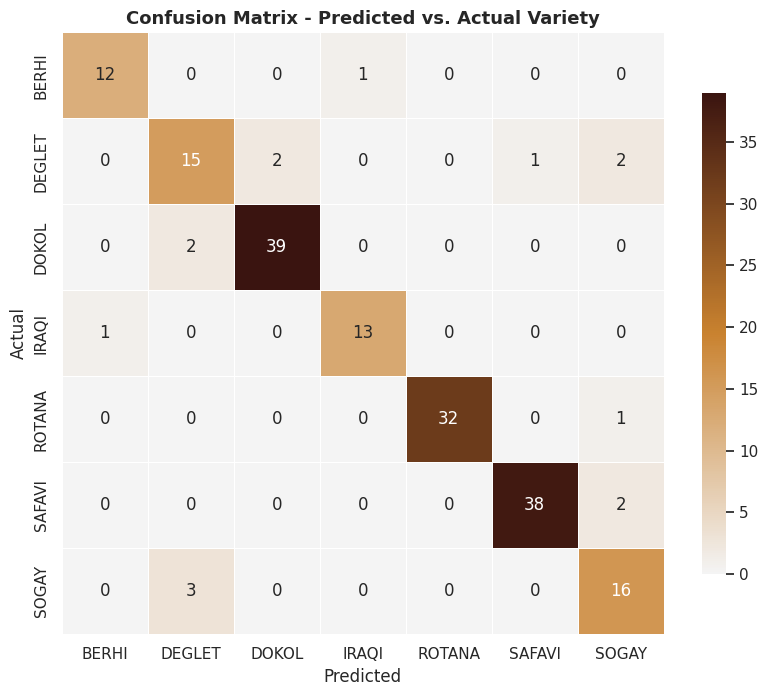

In [13]:
from sklearn.metrics import confusion_matrix

labels = sorted(df['Class'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap=sns.blend_palette(['#f4f4f4', AMBER, MAROON], as_cmap=True),
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Confusion Matrix - Predicted vs. Actual Variety', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f80;
    background: #eef7f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2420;
">
<b style="color:#2f8f80; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The matrix pinpoints exactly what the per-class scores only hinted at: <b>DEGLET</b> and <b>SOGAY</b> are mistaken for each other more than for any other variety (2 DEGLET images predicted as SOGAY, 3 SOGAY images predicted as DEGLET &mdash; 5 of their combined errors), and DEGLET is also confused with DOKOL twice. Every other variety, including the small BERHI class, stays almost entirely on the diagonal. This is a specific, fixable pattern &mdash; DEGLET and SOGAY apparently sit close together in feature space &mdash; not a general problem with rare classes.
</div>


<div style="
    background: linear-gradient(100deg, #3a1410 0%, #7a3b1e 50%, #c9822f 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>This dataset is genuinely clean</b>: zero missing values and zero duplicate rows across all 898 images, consistent with it being curated, published research data rather than a raw scrape.</li>
<li><b>Class imbalance is real, but it isn't what drives model difficulty here</b>: a 3.14&times; gap separates the largest variety (DOKOL, 204 images) from the smallest (BERHI, 65) &mdash; yet BERHI was one of the model's best-classified varieties. The real trouble spot was DEGLET and SOGAY getting confused with each other, a specific feature-overlap issue rather than a rare-class problem.</li>
<li><b>Shape and size dominate over color</b> for telling these varieties apart: MINOR_AXIS, CONVEX_AREA, AREA, PERIMETER, and EQDIASQ are the five strongest class-separating features, all well ahead of any color-channel statistic.</li>
<li><b>A perfect correlation isn't always a duplicate column</b>: MeanRG and ALLdaub4RG correlate at exactly 1.000 but differ by a constant scale factor of about 2&times; rather than being identical &mdash; a distinction worth checking precisely rather than assuming from the correlation value alone.</li>
<li><b>A 34-feature Random Forest reaches 91.7% accuracy</b>, closely matching the 92.2&ndash;92.8% range reported in the dataset's original paper (Koklu et al., 2021) using different modeling approaches &mdash; a reassuring sign this notebook's findings are consistent with the published research this data comes from.</li>
<li>This is real image-derived research data with a specific citation request (see the dataset's accompanying citation file); any reuse of the findings here should credit the original paper rather than this notebook.</li>
</ul>
</div>
